# Homework — Multiprocessing & Functional Programming

**Course:** Big Data  
**Student:** Sergey

This notebook contains solutions for two beginner-level tasks:

1. Multiprocessing with `yfinance`
2. Functional programming in Python

## Part 1 — Multiprocessing

In this section, I use the `yfinance` library to download stock prices for S&P 500 companies and compare:

- single-process downloading
- multiprocessing downloading

Then I save the results and visualize the runtime comparison.

In [1]:
import time
import warnings
from pathlib import Path
from multiprocessing import cpu_count
from concurrent.futures import ProcessPoolExecutor, as_completed

import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import requests

warnings.filterwarnings("ignore")

### 1.1 Quick introduction to `yfinance`

`yfinance` is a Python library used to download historical stock price data from Yahoo Finance.

Below is a simple example of downloading 1 year of Apple stock data.

In [2]:
example_df = yf.download("AAPL", period="1y", progress=False)
example_df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2025-03-14,212.563553,213.021548,208.670517,210.333268,60107600
2025-03-17,213.071365,214.286072,209.058854,212.384357,48073400
2025-03-18,211.767044,214.216361,210.572254,213.230666,42432400
2025-03-19,214.305969,217.810683,212.822430,213.290391,54385400
2025-03-20,213.170914,216.546202,211.299067,213.061390,48862900


### 1.2 Creating folders for saved files

The downloaded stock data will be saved into separate folders for:

- single process
- multiprocessing

In [3]:
OUTPUT_DIR = Path("output_stock_data")
OUTPUT_DIR.mkdir(exist_ok=True)

SINGLE_DIR = OUTPUT_DIR / "single_process"
MULTI_DIR = OUTPUT_DIR / "multi_process"

SINGLE_DIR.mkdir(exist_ok=True)
MULTI_DIR.mkdir(exist_ok=True)

PERIODS = ["1y", "5y"]

### 1.3 Getting S&P 500 tickers

The function below reads the list of S&P 500 companies from Wikipedia.

A fallback list is included in case the website does not respond.

In [4]:
def get_sp500_tickers(limit=None):
    url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

    headers = {
        "User-Agent": (
            "Mozilla/5.0 (X11; Linux x86_64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/122.0.0.0 Safari/537.36"
        )
    }

    try:
        response = requests.get(url, headers=headers, timeout=30)
        response.raise_for_status()

        tables = pd.read_html(response.text)
        df = tables[0]

        tickers = (
            df["Symbol"]
            .astype(str)
            .str.strip()
            .str.replace(".", "-", regex=False)
            .tolist()
        )

    except Exception as e:
        print("Wikipedia request failed. Using fallback tickers.")
        tickers = ["AAPL", "MSFT", "NVDA", "AMZN", "META", "GOOGL", "TSLA", "JPM", "V", "JNJ"]

    if limit is not None:
        tickers = tickers[:limit]

    return tickers

### 1.4 Downloading and saving one ticker

This function downloads one ticker for a given period and saves it as a CSV file.

In [5]:
def download_one_ticker(ticker, period, out_dir):
    start = time.perf_counter()

    try:
        df = yf.download(
            ticker,
            period=period,
            interval="1d",
            progress=False,
            threads=False
        )

        if df.empty:
            return {
                "ticker": ticker,
                "status": "empty",
                "seconds": round(time.perf_counter() - start, 4)
            }

        df["Ticker"] = ticker
        df.reset_index(inplace=True)

        out_dir = Path(out_dir)
        out_dir.mkdir(parents=True, exist_ok=True)

        df.to_csv(out_dir / f"{ticker}_{period}.csv", index=False)

        return {
            "ticker": ticker,
            "status": "ok",
            "seconds": round(time.perf_counter() - start, 4)
        }

    except Exception as e:
        return {
            "ticker": ticker,
            "status": f"error: {e}",
            "seconds": round(time.perf_counter() - start, 4)
        }

### 1.5 Single-process downloading

This version downloads tickers one by one in sequence.

In [6]:
def run_single_process(tickers, period, out_dir):
    results = []
    start = time.perf_counter()

    for ticker in tickers:
        result = download_one_ticker(ticker, period, out_dir)
        results.append(result)

    total_time = time.perf_counter() - start
    return pd.DataFrame(results), total_time

### 1.6 Multiprocessing downloading

This version downloads tickers in parallel using multiple processes.

In [7]:
def run_multiprocessing(tickers, period, out_dir):
    results = []
    start = time.perf_counter()

    with ProcessPoolExecutor(max_workers=max(2, cpu_count() - 1)) as executor:
        futures = [
            executor.submit(download_one_ticker, ticker, period, out_dir)
            for ticker in tickers
        ]

        for future in as_completed(futures):
            results.append(future.result())

    total_time = time.perf_counter() - start
    return pd.DataFrame(results), total_time

### 1.7 Running both approaches

To avoid excessive downloading during testing, I first use a limited number of tickers.

In [8]:
tickers = get_sp500_tickers(limit=30)
print("Number of tickers used:", len(tickers))
print(tickers[:10])

Number of tickers used: 30
['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A']


In [9]:
summaries = []

for period in PERIODS:
    print(f"\nRunning for period: {period}")

    single_df, single_time = run_single_process(tickers, period, SINGLE_DIR / period)
    multi_df, multi_time = run_multiprocessing(tickers, period, MULTI_DIR / period)

    summaries.append({
        "period": period,
        "method": "single",
        "time_sec": single_time
    })

    summaries.append({
        "period": period,
        "method": "multi",
        "time_sec": multi_time
    })

    print(f"Single-process time: {single_time:.2f} sec")
    print(f"Multiprocessing time: {multi_time:.2f} sec")
    print(f"Speedup: {single_time / multi_time:.2f}x")


Running for period: 1y
Single-process time: 12.75 sec
Multiprocessing time: 4.38 sec
Speedup: 2.91x

Running for period: 5y
Single-process time: 10.94 sec
Multiprocessing time: 5.93 sec
Speedup: 1.85x


### 1.8 Summary table

In [10]:
summary_df = pd.DataFrame(summaries)
summary_df

,period,method,time_sec
0,1y,single,12.754703
1,1y,multi,4.382323
2,5y,single,10.935009
3,5y,multi,5.925536


### 1.9 Visualization of runtime comparison

The bar chart below compares the runtime of single processing and multiprocessing.

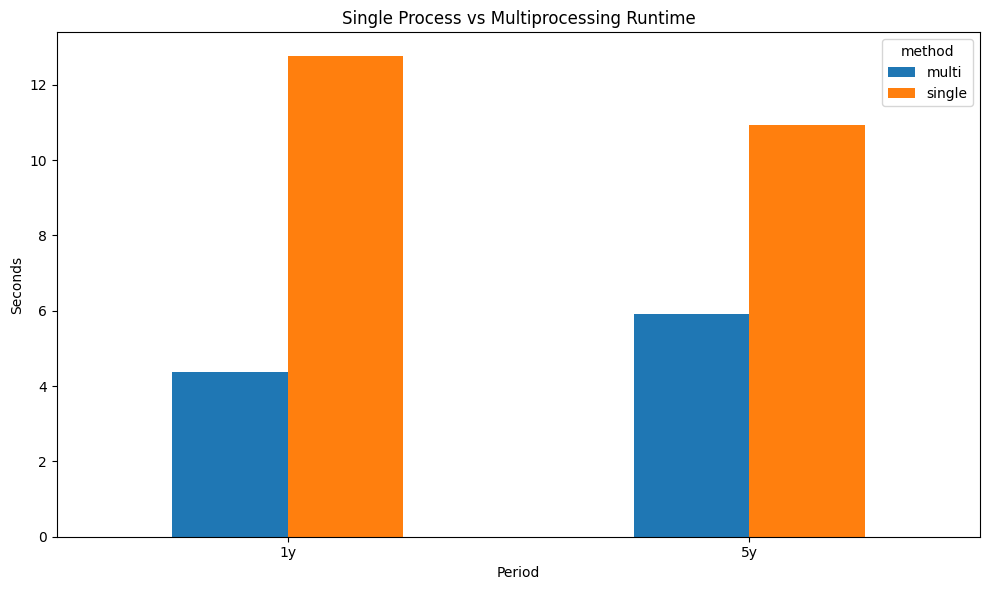

In [11]:
pivot_df = summary_df.pivot(index="period", columns="method", values="time_sec")

pivot_df.plot(kind="bar", figsize=(10, 6))
plt.title("Single Process vs Multiprocessing Runtime")
plt.ylabel("Seconds")
plt.xlabel("Period")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Part 2 — Functional Programming

In this section, I use:

- `map()`
- `filter()`
- `functools.reduce()`
- `lambda`
- `DataFrame.apply()`

to solve small functional-programming tasks in Python.

### 2.1 Defining the list

In [12]:
ls = [1, 2, 3, 4, 5, 6, 7, 8, 9]
ls

[1, 2, 3, 4, 5, 6, 7, 8, 9]

### 2.A1 — Basic implementation (own effort)

First, I solve the task in a simple beginner-friendly way.

In [13]:
from functools import reduce

In [14]:
def is_prime_basic(n):
    if n < 2:
        return False
    for i in range(2, n):
        if n % i == 0:
            return False
    return True

In [15]:
squared_basic = list(map(lambda x: x**2, ls))
primes_basic = list(filter(is_prime_basic, ls))
sum_of_squares_basic = reduce(lambda acc, x: acc + x**2, ls, 0)

actual_basic = [1, 2, 3, 4, 5]
predicted_basic = [1.1, 1.9, 3.2, 3.8, 5.3]

squared_errors_basic = list(map(lambda pair: (pair[0] - pair[1])**2, zip(actual_basic, predicted_basic)))
mse_basic = reduce(lambda acc, x: acc + x, squared_errors_basic, 0) / len(squared_errors_basic)

print("Squared numbers:", squared_basic)
print("Prime numbers:", primes_basic)
print("Sum of squares:", sum_of_squares_basic)
print("Squared errors:", squared_errors_basic)
print("MSE:", mse_basic)

Squared numbers: [1, 4, 9, 16, 25, 36, 49, 64, 81]
Prime numbers: [2, 3, 5, 7]
Sum of squares: 285
Squared errors: [0.010000000000000018, 0.010000000000000018, 0.04000000000000007, 0.04000000000000007, 0.0899999999999999]
MSE: 0.03800000000000001


### 2.A2 — Improved implementation (after research)

Below is a cleaner and slightly more efficient version of the same tasks.

In [16]:
from math import sqrt

In [17]:
def is_prime_improved(n):
    if n < 2:
        return False
    for i in range(2, int(sqrt(n)) + 1):
        if n % i == 0:
            return False
    return True

In [18]:
squared_improved = list(map(lambda x: x * x, ls))
primes_improved = list(filter(is_prime_improved, ls))
sum_of_squares_improved = reduce(lambda acc, x: acc + x * x, ls, 0)

actual_improved = [1, 2, 3, 4, 5]
predicted_improved = [1.1, 1.9, 3.2, 3.8, 5.3]

mse_improved = reduce(
    lambda acc, pair: acc + (pair[0] - pair[1])**2,
    zip(actual_improved, predicted_improved),
    0
) / len(actual_improved)

print("Squared numbers:", squared_improved)
print("Prime numbers:", primes_improved)
print("Sum of squares:", sum_of_squares_improved)
print("MSE:", mse_improved)

Squared numbers: [1, 4, 9, 16, 25, 36, 49, 64, 81]
Prime numbers: [2, 3, 5, 7]
Sum of squares: 285
MSE: 0.03800000000000001


### 2.2 Explanation

- `map()` applies a function to every element of a list
- `filter()` keeps only elements that satisfy a condition
- `reduce()` combines all elements into one final value

These functions make the code compact and expressive.

### 2.3 Using lambda functions with `DataFrame.apply()`

Now I use lambda functions with pandas `apply()` to mutate columns and create new columns.

In [19]:
df_people = pd.DataFrame({
    "name": ["ani", "aram", "mari", "david"],
    "salary": [180000, 250000, 320000, 150000],
    "experience_years": [1, 3, 5, 0]
})

df_people

,name,salary,experience_years
0,ani,180000,1
1,aram,250000,3
2,mari,320000,5
3,david,150000,0


In [20]:
df_people["name"] = df_people["name"].apply(lambda x: x.capitalize())
df_people["salary_k"] = df_people["salary"].apply(lambda x: x / 1000)

df_people["salary_level"] = df_people["salary"].apply(
    lambda x: "High" if x >= 300000 else ("Medium" if x >= 200000 else "Low")
)

df_people["bonus"] = df_people.apply(
    lambda row: row["salary"] * 0.20 if row["experience_years"] >= 3 else row["salary"] * 0.10,
    axis=1
)

df_people["total_income"] = df_people.apply(
    lambda row: row["salary"] + row["bonus"],
    axis=1
)

df_people

,name,salary,experience_years,salary_k,salary_level,bonus,total_income
0,Ani,180000,1,180.0,Low,18000.0,198000.0
1,Aram,250000,3,250.0,Medium,50000.0,300000.0
2,Mari,320000,5,320.0,High,64000.0,384000.0
3,David,150000,0,150.0,Low,15000.0,165000.0
